# NautiCost — Cost Prediction Modeling

Predict `final_charge` per yacht service transaction.

**Approach:** LightGBM (primary) + Ridge baseline, time-based split, log-transformed target.
See `../../.claude/plans/staged-swimming-treehouse.md` for the full plan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

pd.set_option('display.max_columns', 50)
RNG = 42

## 1. Load data

In [2]:
DATA = Path('../004 data/costs_merged.csv')
df = pd.read_csv(DATA)
print(df.shape)
df.head()

(1654, 26)


,yacht_id,office,arrival_port,arrival_date,departure_date,service_type,invoice_comments,supplier,cost_no_vat,final_charge,year,month,stay_days,margin,service_category,flag,gt,nt,loa_m,reg_length_m,beam_m,draft_m,air_draft_m,fuel_lph,loskrav,size_category
0,yacht_10,Bergen Office,Bergen,2024-09-13 00:00:00,2024-09-21 00:00:00,Repair of,Bike Repair + Bike Pump,Unidentified Supplier,335.68,457.98,2024,9,8.0,122.30,Technical Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
1,yacht_10,Bergen Office,Bergen,2024-09-15 00:00:00,2024-09-25 00:00:00,Transfer Service,Transfer - Embarking + Disembarking Crew,Unidentified Supplier,576.87,917.27,2024,9,10.0,340.40,Hospitality,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
2,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-26 00:00:00,Purchasing Assistance,Purchase Assistance - SD Charts,Unidentified Supplier,201.73,247.15,2024,9,8.0,45.42,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
3,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-26 00:00:00,Custom Formalities,Entry Clearance into Norway,NaN,0.00,251.04,2024,9,8.0,251.04,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor
4,yacht_10,Bergen Office,Bergen,2024-09-18 00:00:00,2024-09-28 00:00:00,Purchasing Assistance,Purchase Assistance - Beers,Unidentified Supplier,160.86,221.49,2024,9,10.0,60.63,Agency Services,NaN,497.0,149.0,53.25,50.88,9.2,3.05,17.0,130.0,Nei,Mellomstor


In [3]:
# Drop rows with missing target
df = df.dropna(subset=['final_charge'])
df = df[df['final_charge'] > 0].copy()
print('After filtering:', df.shape)
df['final_charge'].describe()

After filtering: (1633, 26)


count      1633.000000
mean      25044.820269
std       57589.474465
min          15.110000
25%        2039.060000
50%        7512.970000
75%       21950.000000
max      657504.100000
Name: final_charge, dtype: float64

## 2. Features and target

In [4]:
CAT_FEATURES = ['office', 'arrival_port', 'service_type', 'service_category', 'size_category', 'loskrav']
NUM_FEATURES = ['gt', 'loa_m', 'beam_m', 'draft_m', 'stay_days', 'month']
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET = 'final_charge'

for c in CAT_FEATURES:
    df[c] = df[c].astype('category')

df[FEATURES].dtypes

office              category
arrival_port        category
service_type        category
service_category    category
size_category       category
loskrav             category
gt                   float64
loa_m                float64
beam_m               float64
draft_m              float64
stay_days            float64
month                  int64
dtype: object

### 2b. Feature engineering
Temporal, interaction, and text-based features derived from existing columns.

In [5]:
def build_features(df, agg_stats=None):
    """Add engineered features.
    agg_stats: tuple of (size_svc_stats, size_stats, port_stats) DataFrames.
    If None, fit on rows where year<=2024.
    """
    df = df.copy()

    # Temporal
    df['quarter'] = ((df['month'] - 1) // 3 + 1).astype('int8')
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype('int8')
    df['is_shoulder'] = df['month'].isin([5, 9]).astype('int8')

    # Numeric interactions
    df['gt_x_stay']   = df['gt'].fillna(0) * df['stay_days'].fillna(0)
    df['loa_x_stay']  = df['loa_m'].fillna(0) * df['stay_days'].fillna(0)
    df['fuel_x_stay'] = df['fuel_lph'].fillna(0) * df['stay_days'].fillna(0)

    # Size-category x service-category aggregates (generalizes to unseen yachts)
    if agg_stats is None:
        hist = df[df['year'] <= 2024]
        size_svc_stats = hist.groupby(['size_category', 'service_category'])['final_charge'].agg(
            size_svc_mean_charge='mean',
            size_svc_median_charge='median',
            size_svc_count='count'
        ).reset_index()
        size_stats = hist.groupby('size_category')['final_charge'].agg(
            size_mean_charge='mean', size_count='count'
        ).reset_index()
        port_stats = hist.groupby('arrival_port')['final_charge'].agg(
            port_mean_charge='mean', port_median_charge='median'
        ).reset_index()
        agg_stats = (size_svc_stats, size_stats, port_stats)

    size_svc_stats, size_stats, port_stats = agg_stats
    df = df.merge(size_svc_stats, on=['size_category', 'service_category'], how='left')
    df = df.merge(size_stats, on='size_category', how='left')
    df = df.merge(port_stats, on='arrival_port', how='left')

    # Fill missing stats with global medians
    for col in ['size_svc_mean_charge', 'size_svc_median_charge', 'size_svc_count',
                'port_mean_charge', 'port_median_charge']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median() if df[col].notna().any() else 0)

    # Text signal from invoice_comments (length only — keyword flags had zero/near-zero importance)
    cmt = df['invoice_comments'].fillna('').astype(str).str.lower()
    df['cmt_len'] = cmt.str.len().astype('int16')

    return df, agg_stats

# Dropped 7 low-importance/redundant features:
#   log_gt (r=0.94 with gt), fuel_lph (r=0.999 with gt), size_mean_charge (gain<1),
#   size_count (gain=0), cmt_has_urgent (0 positives), cmt_has_repair (gain=0), cmt_has_fuel (gain<2)
NEW_NUM = ['quarter','is_summer','is_shoulder','gt_x_stay','loa_x_stay','fuel_x_stay',
           'size_svc_mean_charge','size_svc_median_charge','size_svc_count',
           'port_mean_charge','port_median_charge',
           'cmt_len']
NUM_FEATURES = NUM_FEATURES + NEW_NUM
FEATURES = CAT_FEATURES + NUM_FEATURES

df, agg_stats = build_features(df)
print(f'Total features: {len(FEATURES)} ({len(CAT_FEATURES)} cat + {len(NUM_FEATURES)} num)')
print('Engineered features:', NEW_NUM)

Total features: 24 (6 cat + 18 num)
Engineered features: ['quarter', 'is_summer', 'is_shoulder', 'gt_x_stay', 'loa_x_stay', 'fuel_x_stay', 'size_svc_mean_charge', 'size_svc_median_charge', 'size_svc_count', 'port_mean_charge', 'port_median_charge', 'cmt_len']


## 3. Time-based split
train ≤ 2024, val = 2025, test = 2026

In [6]:
train = df[df['year'] <= 2024]
val   = df[df['year'] == 2025]
test  = df[df['year'] == 2026]
print('train', train.shape, 'val', val.shape, 'test', test.shape)

def xy(sub):
    X = sub[FEATURES].copy()
    y = np.log1p(sub[TARGET].values)
    return X, y

X_tr, y_tr = xy(train)
X_va, y_va = xy(val)
X_te, y_te = xy(test)

train (977, 40) val (649, 40) test (7, 40)


## 4. Baseline: median predictor & Ridge

In [7]:
def eval_pred(y_true_log, y_pred_log, label):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE with floor of 500 NOK to avoid tiny charges inflating the metric
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 500))) * 100
    print(f'{label:20s} MAE={mae:10.0f}  RMSE={rmse:10.0f}  MAPE={mape:6.1f}%')
    return mae, rmse, mape

med = np.median(y_tr)
eval_pred(y_va, np.full_like(y_va, med), 'Median baseline')

Median baseline      MAE=     23103  RMSE=     65949  MAPE= 273.7%


(23102.974314329735,
 np.float64(65949.30869352716),
 np.float64(273.7392262788603))

In [8]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
])
ridge = Pipeline([('pre', pre), ('reg', Ridge(alpha=1.0, random_state=RNG))])
ridge.fit(X_tr.fillna(-1), y_tr)
eval_pred(y_va, ridge.predict(X_va.fillna(-1)), 'Ridge (val)')

Ridge (val)          MAE=     19246  RMSE=     60755  MAPE= 135.1%


(19246.176810836183,
 np.float64(60754.5496295623),
 np.float64(135.08158776974744))

## 5. LightGBM

In [9]:
lgb_params = dict(
    objective='huber',
    alpha=1.0,           # Huber delta — robust to outlier transactions
    metric='mae',
    learning_rate=0.05,
    num_leaves=40,
    min_data_in_leaf=30,
    max_depth=6,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    random_state=RNG,
    verbose=-1,
)

dtrain = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
dval   = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtrain)

model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 50 rounds


[100]	train's l1: 0.65245	val's l1: 0.876872


[200]	train's l1: 0.544259	val's l1: 0.82784


[300]	train's l1: 0.484041	val's l1: 0.805689
[400]	train's l1: 0.438073	val's l1: 0.7831


[500]	train's l1: 0.401948	val's l1: 0.769972
[600]	train's l1: 0.371494	val's l1: 0.754358


...

[800]	train's l1: 0.325363	val's l1: 0.735489
[900]	train's l1: 0.309186	val's l1: 0.726018


[1000]	train's l1: 0.295354	val's l1: 0.720882
[1100]	train's l1: 0.282802	val's l1: 0.714127


[1200]	train's l1: 0.271647	val's l1: 0.708978


[1300]	train's l1: 0.260249	val's l1: 0.704623
[1400]	train's l1: 0.250426	val's l1: 0.701054


[1500]	train's l1: 0.240968	val's l1: 0.699212
Early stopping, best iteration is:
[1471]	train's l1: 0.244002	val's l1: 0.698674


In [10]:
pred_va = model.predict(X_va, num_iteration=model.best_iteration)
eval_pred(y_va, pred_va, 'LightGBM (val)')

if len(X_te):
    pred_te = model.predict(X_te, num_iteration=model.best_iteration)
    eval_pred(y_te, pred_te, 'LightGBM (test)')

LightGBM (val)       MAE=     15091  RMSE=     51528  MAPE= 104.6%
LightGBM (test)      MAE=     20279  RMSE=     29567  MAPE=  26.4%


## 6. Feature importance

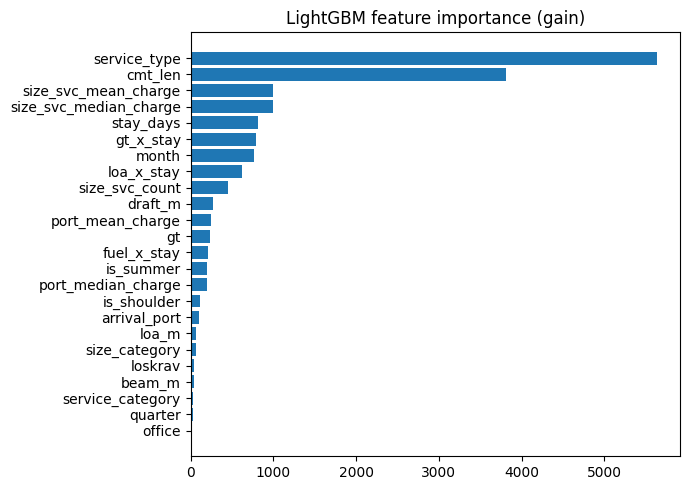

In [11]:
imp = pd.DataFrame({
    'feature': model.feature_name(),
    'gain': model.feature_importance(importance_type='gain'),
}).sort_values('gain', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'], imp['gain'])
ax.set_title('LightGBM feature importance (gain)')
plt.tight_layout()
plt.show()

## 7. Quantile predictions (P10 / P50 / P90)

In [12]:
# Quantile models are trained after Optuna tuning (see section 9b below)
# to use the tuned hyperparameters for better calibration.
print('Quantile models will be trained after hyperparameter tuning (section 9b).')

Quantile models will be trained after hyperparameter tuning (section 9b).


## 8. CatBoost (native categorical handling)

In [13]:
from catboost import CatBoostRegressor

X_tr_cb = X_tr.copy()
X_va_cb = X_va.copy()
for c in CAT_FEATURES:
    X_tr_cb[c] = X_tr_cb[c].astype(str).fillna('NA')
    X_va_cb[c] = X_va_cb[c].astype(str).fillna('NA')

cb = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=6,
    loss_function='MAE', cat_features=CAT_FEATURES,
    early_stopping_rounds=50, random_seed=RNG, verbose=0,
)
cb.fit(X_tr_cb, y_tr, eval_set=(X_va_cb, y_va))
eval_pred(y_va, cb.predict(X_va_cb), 'CatBoost (val)')

CatBoost (val)       MAE=     17066  RMSE=     60199  MAPE= 111.3%


(17066.402338678658,
 np.float64(60198.51141869209),
 np.float64(111.30973556148642))

## 9. Hyperparameter tuning with Optuna (LightGBM)

In [14]:
import optuna
from sklearn.model_selection import KFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Combine train + val for CV (test=2026 stays fully held out)
X_cv = pd.concat([X_tr, X_va], ignore_index=True)
y_cv = np.concatenate([y_tr, y_va])

def objective(trial):
    p = dict(
        objective='huber', metric='mae', verbose=-1, random_state=RNG,
        alpha=trial.suggest_float('alpha', 0.5, 5.0),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 50),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 25, 80),
        max_depth=trial.suggest_int('max_depth', 3, 6),
        feature_fraction=trial.suggest_float('feature_fraction', 0.5, 0.85),
        bagging_fraction=trial.suggest_float('bagging_fraction', 0.5, 0.85),
        bagging_freq=5,
        lambda_l1=trial.suggest_float('lambda_l1', 0.1, 10, log=True),
        lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10, log=True),
    )
    kf = KFold(n_splits=5, shuffle=True, random_state=RNG)
    fold_maes = []
    for train_idx, val_idx in kf.split(X_cv):
        Xf_tr, yf_tr = X_cv.iloc[train_idx], y_cv[train_idx]
        Xf_va, yf_va = X_cv.iloc[val_idx], y_cv[val_idx]
        dtr = lgb.Dataset(Xf_tr, yf_tr, categorical_feature=CAT_FEATURES)
        dva = lgb.Dataset(Xf_va, yf_va, categorical_feature=CAT_FEATURES, reference=dtr)
        m = lgb.train(p, dtr, num_boost_round=1500, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        pred = m.predict(Xf_va, num_iteration=m.best_iteration)
        fold_maes.append(mean_absolute_error(np.expm1(yf_va), np.expm1(pred)))
    return np.mean(fold_maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=80, show_progress_bar=False)
print('Best CV MAE:', study.best_value)
print('Best params:', study.best_params)

Best CV MAE: 13359.358942106483
Best params: {'alpha': 2.681113788835814, 'learning_rate': 0.09980034091667374, 'num_leaves': 26, 'min_data_in_leaf': 29, 'max_depth': 6, 'feature_fraction': 0.6837659116567434, 'bagging_fraction': 0.8403851612670235, 'lambda_l1': 0.8489263168995368, 'lambda_l2': 0.18558719501727103}


In [15]:
# Train tuned model on original train split, validate on val split (for comparison with base models)
tuned_params = dict(objective='huber', metric='mae', verbose=-1,
                    random_state=RNG, bagging_freq=5, **study.best_params)
dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtr)
best_model = lgb.train(
    tuned_params, dtr, num_boost_round=2000, valid_sets=[dtr, dva],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
pred_tr = best_model.predict(X_tr, num_iteration=best_model.best_iteration)
pred_va = best_model.predict(X_va, num_iteration=best_model.best_iteration)
eval_pred(y_tr, pred_tr, 'Tuned LGB (train)')
eval_pred(y_va, pred_va, 'Tuned LGB (val)')

# Report train/val gap
tr_l1 = mean_absolute_error(y_tr, pred_tr)
va_l1 = mean_absolute_error(y_va, pred_va)
print(f'\nTrain/val log-L1 gap: {tr_l1:.4f} / {va_l1:.4f} = {va_l1/tr_l1:.1f}x')

Tuned LGB (train)    MAE=      7695  RMSE=     29395  MAPE=  29.0%
Tuned LGB (val)      MAE=     15585  RMSE=     52766  MAPE= 106.8%

Train/val log-L1 gap: 0.2670 / 0.7333 = 2.7x


### 9b. Quantile predictions with tuned params + CQR calibration

In [16]:
quantile_models = {}
for q in [0.1, 0.5, 0.9]:
    # Use tuned params as base, with extra regularization for quantile stability
    p = {**tuned_params, 'objective': 'quantile', 'alpha': q, 'metric': 'quantile',
         'feature_pre_filter': False}  # Allow dynamic min_data_in_leaf changes
    p['min_data_in_leaf'] = max(p.get('min_data_in_leaf', 25), 25)
    p['num_leaves'] = min(p.get('num_leaves', 31), 31)
    dtr_q = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_FEATURES)
    dva_q = lgb.Dataset(X_va, y_va, categorical_feature=CAT_FEATURES, reference=dtr_q)
    m = lgb.train(p, dtr_q, num_boost_round=best_model.best_iteration or 500,
                  valid_sets=[dva_q], callbacks=[lgb.log_evaluation(0)])
    quantile_models[q] = m

# Raw quantile predictions
p10_raw = np.expm1(quantile_models[0.1].predict(X_va))
p50_raw = np.expm1(quantile_models[0.5].predict(X_va))
p90_raw = np.expm1(quantile_models[0.9].predict(X_va))
actual = np.expm1(y_va)

# Fix quantile crossing: sort per-row so P10 <= P50 <= P90
stacked = np.column_stack([p10_raw, p50_raw, p90_raw])
stacked_sorted = np.sort(stacked, axis=1)
p10, p50, p90 = stacked_sorted[:, 0], stacked_sorted[:, 1], stacked_sorted[:, 2]

# Conformal Quantile Regression (CQR) correction for guaranteed coverage
# Conformity scores: how much must we widen the band?
scores = np.maximum(p10 - actual, actual - p90)
cqr_alpha = 0.2  # Target 80% coverage
q_correction = np.quantile(scores, 1 - cqr_alpha)
p10_adj = p10 - q_correction
p90_adj = p90 + q_correction

print(f'CQR correction: {q_correction:,.0f} NOK')
print()

# Coverage check
cov_raw = np.mean((actual >= p10) & (actual <= p90)) * 100
cov_adj = np.mean((actual >= p10_adj) & (actual <= p90_adj)) * 100
print(f'[P10, P90] raw coverage:      {cov_raw:5.1f}%  (nominal 80%)')
print(f'[P10, P90] CQR-adj coverage:  {cov_adj:5.1f}%  (nominal 80%)')
print()

out = pd.DataFrame({
    'actual': actual,
    'p10': p10_adj, 'p50': p50, 'p90': p90_adj,
}).head(15)
out

CQR correction: 3,687 NOK

[P10, P90] raw coverage:       50.7%  (nominal 80%)
[P10, P90] CQR-adj coverage:   80.0%  (nominal 80%)



,actual,p10,p50,p90
0,1288.10,-2352.297935,3485.447184,9795.263625
1,2772.00,-2516.234663,2526.654152,9002.447895
2,11869.00,-1507.004219,6872.799482,11621.399451
3,2200.00,-2599.846413,2461.866372,8292.841039
4,15342.25,4123.134737,10500.290754,30636.826545
5,5549.50,-3207.634019,3321.263051,9531.859753
6,1994.86,-2701.426485,1669.576755,8485.818352
7,4799.41,1963.783926,6137.115600,21451.477563
8,1500.13,-2701.426485,1669.576755,8485.818352
9,365.20,-3370.307446,1277.050881,7239.883098


## 10. SHAP explainability

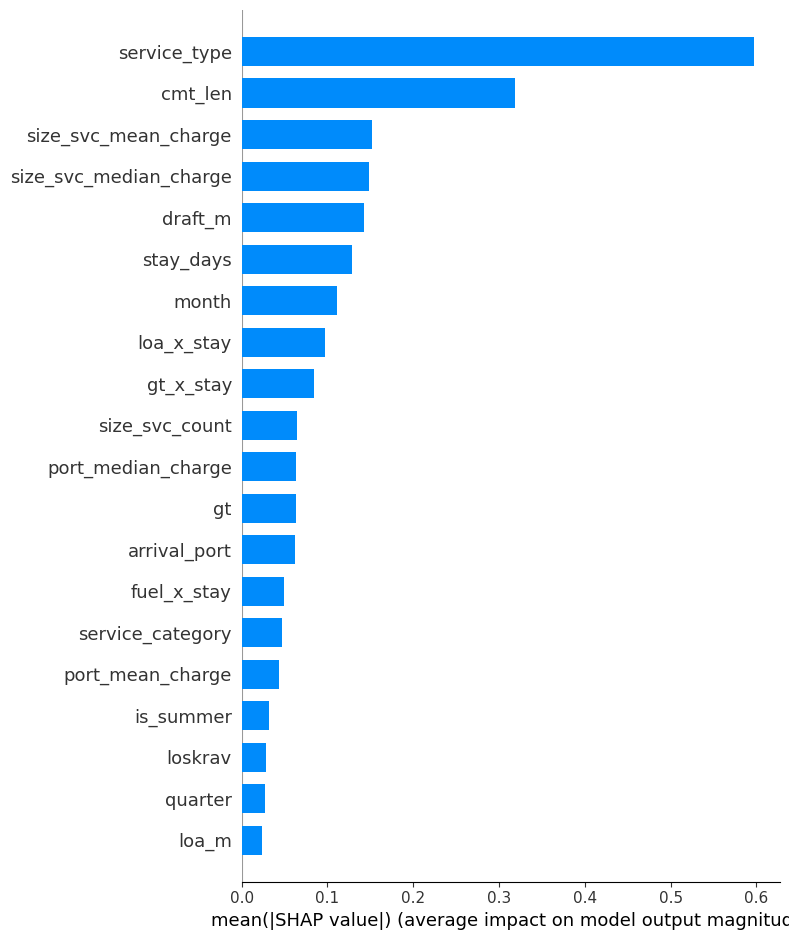

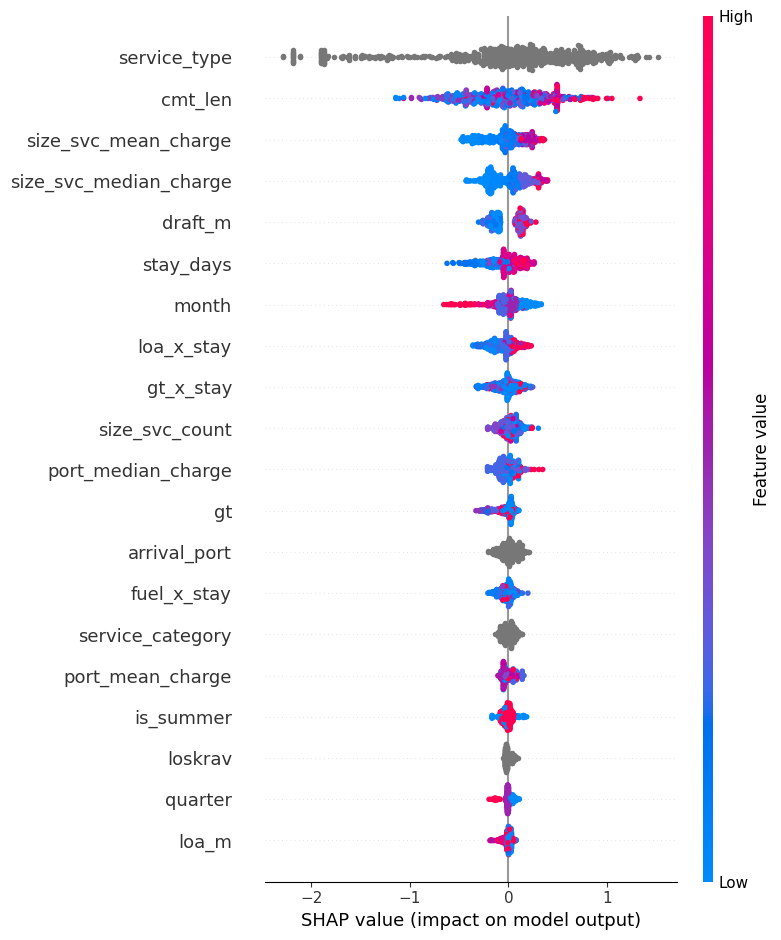

In [17]:
try:
    import shap
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_va)
    shap.summary_plot(shap_values, X_va, plot_type='bar', show=False)
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_values, X_va, show=False)
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'SHAP unavailable ({e}), skipping explainability plots.')

In [18]:
try:
    # Per-row explanation: top 5 rows with largest prediction
    pred_va = best_model.predict(X_va, num_iteration=best_model.best_iteration)
    top_idx = np.argsort(-pred_va)[:5]
    for i in top_idx:
        print(f"row={i}  actual={np.expm1(y_va[i]):,.0f}  predicted={np.expm1(pred_va[i]):,.0f}")
        contribs = pd.Series(shap_values[i], index=FEATURES).sort_values(key=np.abs, ascending=False)
        print(contribs.head(5).to_string(), '\n')
except NameError:
    print('SHAP values not available, skipping per-row explanations.')

row=308  actual=550,000  predicted=230,667
service_type              1.029659
draft_m                   0.279714
size_svc_median_charge    0.278010
size_svc_mean_charge      0.269811
arrival_port              0.198944 

row=309  actual=388,468  predicted=160,651
service_type              1.221919
cmt_len                   0.840140
draft_m                   0.197427
size_svc_mean_charge      0.181820
size_svc_median_charge    0.178590 

row=290  actual=176,556  predicted=124,301
service_type              1.080159
port_median_charge        0.348039
size_svc_mean_charge      0.323697
size_svc_median_charge    0.209970
gt_x_stay                 0.182677 

row=340  actual=657,504  predicted=119,516
service_type            1.129388
cmt_len                 1.011977
gt_x_stay               0.247797
size_svc_mean_charge    0.245731
port_median_charge     -0.177385 

row=275  actual=29,620  predicted=116,504
service_type              1.050969
cmt_len                   0.470631
port_median_charge

## 11. Residual diagnostics
Where does the tuned model err? Look at residuals vs predicted, by segment, and inspect the worst misses.

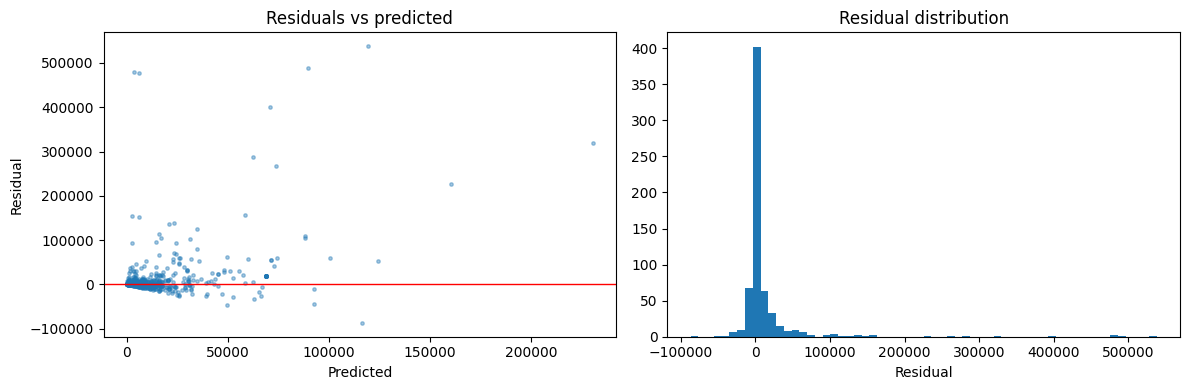

Mean residual:   11,883
Median residual: 830
Std residual:    51,411


In [19]:
pred_va_lin = np.expm1(best_model.predict(X_va, num_iteration=best_model.best_iteration))
actual_va = np.expm1(y_va)
resid = actual_va - pred_va_lin

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_va_lin, resid, s=6, alpha=0.4)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual'); axes[0].set_title('Residuals vs predicted')
axes[1].hist(resid, bins=60)
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()

print(f'Mean residual:   {resid.mean():,.0f}')
print(f'Median residual: {np.median(resid):,.0f}')
print(f'Std residual:    {resid.std():,.0f}')

In [20]:
diag = val[FEATURES + [TARGET]].copy()
diag['pred'] = pred_va_lin
diag['abs_err'] = np.abs(resid)
diag['ape'] = diag['abs_err'] / np.maximum(diag[TARGET], 1)

by_service = diag.groupby('service_category', observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By service_category:'); print(by_service, '\n')

by_size = diag.groupby('size_category', observed=True).agg(
    n=('pred', 'size'), mae=('abs_err', 'mean'), mape=('ape', 'mean')
).sort_values('mae', ascending=False)
print('By size_category:'); print(by_size)

By service_category:
                      n           mae       mape
service_category                                
Provisioning         71  45318.529553  17.539574
Bunkering            20  38305.046495   0.436925
Port Marina         144  18861.275240   0.998279
Technical Services   48  17195.957602   0.665442
Agency Fee           25  12557.591888   1.775129
Hospitality         121  10551.610316   1.235476
Agency Services     220   4540.433025   1.032797 

By size_category:
                 n           mae      mape
size_category                             
Stor           226  26525.069692  0.978940
Mellomstor     214  10154.415891  0.804778
Liten          209   9315.862620  6.973038


In [21]:
worst = diag.nlargest(10, 'abs_err')[['service_category','size_category','gt','stay_days', TARGET,'pred','abs_err']]
worst

,service_category,size_category,gt,stay_days,final_charge,pred,abs_err
1318,Provisioning,Stor,2407.0,10.0,657504.10,119516.029809,537988.070191
1396,Port Marina,Stor,2149.0,27.0,577570.00,89664.719623,487905.280377
1234,Provisioning,Stor,2407.0,2.0,484028.60,3679.762270,480348.837730
1250,Provisioning,Stor,2407.0,2.0,484028.60,5987.281529,478041.318471
1421,Port Marina,Stor,2149.0,27.0,470574.50,70900.840333,399673.659667
1286,Hospitality,Stor,2407.0,6.0,550000.00,230666.739879,319333.260121
1366,Provisioning,Stor,2149.0,27.0,349570.63,62357.933319,287212.696681
1261,Port Marina,Stor,2407.0,10.0,340666.00,73985.268328,266680.731672
1287,Provisioning,Stor,2407.0,6.0,388468.30,160650.683669,227817.616331
1375,Agency Fee,Stor,2149.0,27.0,215140.00,58691.466592,156448.533408


## 12. Final test-set evaluation & model artifact

In [22]:
if len(X_te):
    pred_te = best_model.predict(X_te, num_iteration=best_model.best_iteration)
    eval_pred(y_te, pred_te, 'Tuned LightGBM (test)')
else:
    print('No 2026 test rows available.')

Tuned LightGBM (test) MAE=     23045  RMSE=     33370  MAPE=  30.5%


In [23]:
import joblib
ART = Path('artifacts'); ART.mkdir(exist_ok=True)
best_model.save_model(str(ART / 'lgbm_tuned.txt'))
joblib.dump({'features': FEATURES, 'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
             'best_params': study.best_params, 'best_iteration': best_model.best_iteration},
            ART / 'model_meta.joblib')
print('Saved to', ART.resolve())

Saved to C:\Users\jorge\OneDrive - Høgskolen i Molde\LOG650 - Forskningsprosjekt\LOG650_NautiCost\G11-jorgen-individuell\013 fase 3 - review\artifacts


## 13. Final production model — refit on ALL data
Retrain LightGBM with the tuned hyperparameters on train + val + test combined, using `best_iteration` from the validation-tuned model (no early stopping possible without a holdout).

In [24]:
df_final = df[df['year'].between(2020, 2025)].copy()
X_all = df_final[FEATURES].copy()
y_all = np.log1p(df_final[TARGET].values)
print('Full dataset:', X_all.shape, '| years:', sorted(df_final['year'].unique()))

dall = lgb.Dataset(X_all, y_all, categorical_feature=CAT_FEATURES)
final_model = lgb.train(
    tuned_params,
    dall,
    num_boost_round=best_model.best_iteration,
    callbacks=[lgb.log_evaluation(0)],
)
print('Final model trained on', len(X_all), 'rows for', best_model.best_iteration, 'iterations.')

Full dataset: (1626, 24) | years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


Final model trained on 1626 rows for 794 iterations.


In [25]:
final_model.save_model(str(ART / 'lgbm_final_full.txt'))

# Save aggregate stats (replaces yacht_stats)
size_svc_stats, size_stats, port_stats = agg_stats
size_svc_stats.to_parquet(ART / 'size_svc_stats.parquet', index=False)
size_stats.to_parquet(ART / 'size_stats.parquet', index=False)
port_stats.to_parquet(ART / 'port_stats.parquet', index=False)

# Save CQR correction
joblib.dump({'cqr_correction': float(q_correction)}, ART / 'quantile_meta.joblib')

# Save quantile models
for q, m in quantile_models.items():
    m.save_model(str(ART / f'lgbm_quantile_{q:.1f}.txt'))

# Compute baseline predictions per (port, size_category) for voyage calibration.
# IMPORTANT: templates must match predict_voyage.py EXACTLY (full service lists).
_PORT_OFFICE = {
    'Bergen': 'Bergen Office',     'Esbjerg': 'Copenhagen Office',
    'Fredericia': 'Copenhagen Office', 'Göteborg': 'Stockholm OFFICE',
    'Kristiansand': 'Bergen Office', 'København': 'Copenhagen Office',
    'Malmö': 'Stockholm OFFICE',   'Stavanger': 'Bergen Office',
    'Stockholm': 'Stockholm OFFICE', 'Svolvær': 'Bergen Office',
    'Tromsø': 'Bergen Office',     'Ålesund': 'Bergen Office',
}

_PORT_TEMPLATES = {
    'Bergen': [
        ('Provisioning', 'Provisioning', 0.4),
        ('Port Marina', 'Port Dues', 0.3805),
        ('Hospitality', 'Transfer Service', 0.3561),
        ('Agency Services', 'Custom Clearance', 0.2732),
        ('Agency Services', 'Purchasing Assistance', 0.2439),
        ('Port Marina', 'Arrival Pilot Fees', 0.1707),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.1317),
        ('Hospitality', 'Guide Services', 0.1073),
        ('Agency Services', 'Courier', 0.0927),
        ('Technical Services', 'Technical Assistance', 0.0732),
        ('Agency Services', 'Medical Arrangements', 0.0732),
        ('Agency Fee', 'Agency Fees', 0.0732),
        ('Bunkering', 'Fuel - Diesel', 0.0488),
        ('Agency Services', 'Custom Formalities', 0.039),
        ('Agency Services', 'Immigration Formalities', 0.039),
        ('Port Marina', 'Pilot Fees Arrival', 0.039),
        ('Hospitality', 'Tours / Excursions', 0.039),
        ('Hospitality', 'Car Rental', 0.0341),
        ('Port Marina', 'NOx Tax', 0.0293),
        ('Agency Fee', 'Administrative Fees', 0.0293),
        ('Technical Services', 'Technician', 0.0293),
        ('Agency Services', 'Storage & Transport', 0.0293),
        ('Provisioning', 'Provisioning Assistance', 0.0244),
        ('Agency Services', 'Delivery Charge', 0.0244),
        ('Provisioning', 'Florist Services', 0.0244),
        ('Hospitality', 'Airport Transfer', 0.0195),
        ('Technical Services', 'Repair of', 0.0195),
        ('Port Marina', 'Garbage Disposal', 0.0195),
        ('Technical Services', 'Carpenter Service', 0.0195),
        ('Agency Services', 'Agency Services', 0.0146),
        ('Port Marina', 'Sludge/Oil/Water Removal', 0.0146),
        ('Technical Services', 'Hydraulic Services', 0.0146),
        ('Agency Services', 'Doctor/Medical', 0.0146),
        ('Agency Services', 'Delivery Services', 0.0098),
        ('Hospitality', 'Rental Car', 0.0098),
        ('Bunkering', 'Lube Oil Supply', 0.0098),
        ('Technical Services', 'Dry Dock/Shipyard Services', 0.0098),
        ('Technical Services', 'Diver Services', 0.0098),
    ],
    'Esbjerg': [
        ('Port Marina', 'Port Dues', 3.0),
        ('Provisioning', 'Provisioning', 3.0),
        ('Hospitality', 'Transfer Service', 3.0),
        ('Agency Services', 'Custom Clearance', 2.0),
        ('Port Marina', 'Mooring/Unmooring Assistance', 2.0),
        ('Hospitality', 'Transportation', 2.0),
        ('Agency Services', 'Storage & Transport', 2.0),
        ('Agency Services', 'International Transport', 1.0),
        ('Agency Services', 'Purchasing Assistance', 1.0),
        ('Hospitality', 'Hotel Accommodation', 1.0),
        ('Port Marina', 'Dirty Water Removal Service', 1.0),
        ('Technical Services', 'Technical Assistance', 1.0),
    ],
    'Fredericia': [
        ('Hospitality', 'Transfer Service', 5.0),
        ('Port Marina', 'Port Dues', 2.0),
        ('Provisioning', 'Provisioning', 2.0),
        ('Agency Services', 'Medical Arrangements', 1.0),
        ('Hospitality', 'Tours / Excursions', 1.0),
        ('Hospitality', 'Guide Services', 1.0),
        ('Bunkering', 'Fuel - Diesel', 1.0),
        ('Provisioning', 'Florist Services', 1.0),
    ],
    'Göteborg': [
        ('Port Marina', 'Arrival Pilot Fees', 0.7273),
        ('Bunkering', 'Fuel - Diesel', 0.4545),
        ('Agency Services', 'Purchasing Assistance', 0.4545),
        ('Hospitality', 'Transfer Service', 0.4545),
        ('Provisioning', 'Provisioning', 0.3636),
        ('Hospitality', 'Rental Car', 0.2727),
        ('Agency Services', 'Courier', 0.2727),
        ('Agency Fee', 'Agency Fees', 0.1818),
        ('Port Marina', 'Port Dues', 0.1818),
        ('Agency Services', 'Clearance in/out', 0.1818),
        ('Agency Services', 'Delivery Charge', 0.0909),
        ('Agency Services', 'Service', 0.0909),
        ('Hospitality', 'Laundry/Dry Cleaning', 0.0909),
        ('Hospitality', 'Dry Cleaning Services', 0.0909),
        ('Hospitality', 'Car Rental', 0.0909),
        ('Agency Services', 'Speciality Shipment Items', 0.0909),
        ('Agency Services', 'Medical Arrangements', 0.0909),
        ('Technical Services', 'Internet Connection', 0.0909),
        ('Technical Services', 'Technical Assistance', 0.0909),
        ('Technical Services', 'Technician', 0.0909),
    ],
    'Kristiansand': [
        ('Agency Fee', 'Agency Fees', 0.75),
        ('Port Marina', 'Port Dues', 0.75),
        ('Agency Services', 'Clearance in/out', 0.25),
        ('Bunkering', 'Fuel - Diesel', 0.25),
    ],
    'København': [
        ('Hospitality', 'Transfer Service', 0.3158),
        ('Agency Services', 'Purchasing Assistance', 0.2632),
        ('Port Marina', 'Port Dues', 0.2105),
        ('Agency Services', 'Clearance in/out', 0.1842),
        ('Technical Services', 'Technical Assistance', 0.1842),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.1579),
        ('Provisioning', 'Provisioning', 0.1579),
        ('Agency Fee', 'Agency Fees', 0.1053),
        ('Bunkering', 'Fuel - Diesel', 0.1053),
        ('Agency Services', 'Agency Services', 0.0263),
    ],
    'Malmö': [
        ('Technical Services', 'Boat Work', 2.0),
        ('Provisioning', 'Provisioning', 2.0),
        ('Agency Services', 'Agency Services', 1.0),
        ('Hospitality', 'Transfer Service', 1.0),
        ('Hospitality', 'Guide Services', 1.0),
        ('Port Marina', 'Port Dues', 1.0),
        ('Port Marina', 'Mooring/Unmooring Assistance', 1.0),
    ],
    'Stavanger': [
        ('Port Marina', 'Port Dues', 2.0),
        ('Agency Fee', 'Agency Fees', 1.0),
    ],
    'Stockholm': [
        ('Hospitality', 'Transfer Service', 0.5172),
        ('Port Marina', 'Port Dues', 0.4828),
        ('Provisioning', 'Provisioning', 0.3103),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.3103),
        ('Agency Services', 'Purchasing Assistance', 0.2759),
        ('Agency Services', 'Agency Services', 0.2069),
        ('Agency Fee', 'Agent Time & Service', 0.1724),
        ('Hospitality', 'Guide Services', 0.1034),
        ('Agency Fee', 'Agency Fees', 0.1034),
        ('Agency Services', 'Medical Arrangements', 0.1034),
        ('Hospitality', 'Rental Car', 0.1034),
        ('Agency Fee', 'Administrative Fees', 0.069),
        ('Agency Services', 'Courier', 0.069),
        ('Hospitality', 'Tourism or Guide / Tour', 0.069),
        ('Bunkering', 'Fuel - Diesel', 0.069),
        ('Agency Services', 'Parcel Transfer', 0.0345),
        ('Provisioning', 'Florist Services', 0.0345),
    ],
    'Svolvær': [
        ('Agency Services', 'Custom Clearance', 1.186),
        ('Agency Services', 'Purchasing Assistance', 1.093),
        ('Technical Services', 'Technical Assistance', 0.9535),
        ('Hospitality', 'Guide Services', 0.4419),
        ('Hospitality', 'Transfer Service', 0.186),
        ('Port Marina', 'Port Dues', 0.1628),
        ('Technical Services', 'Diver Services', 0.093),
        ('Bunkering', 'Fuel - Diesel', 0.0698),
        ('Hospitality', 'Car Rental', 0.0698),
        ('Hospitality', 'Laundry/Dry Cleaning', 0.0698),
        ('Hospitality', 'Dry Cleaning Services', 0.0465),
        ('Provisioning', 'Provisioning', 0.0465),
    ],
    'Tromsø': [
        ('Agency Services', 'Custom Clearance', 0.6949),
        ('Agency Services', 'Purchasing Assistance', 0.3305),
        ('Agency Services', 'Storage Arrangements', 0.3305),
        ('Port Marina', 'Port Dues', 0.2373),
        ('Port Marina', 'Arrival Pilot Fees', 0.2203),
        ('Agency Services', 'Storage & Transport', 0.2203),
        ('Hospitality', 'Guide Services', 0.1864),
        ('Provisioning', 'Provisioning', 0.178),
        ('Agency Services', 'Courier', 0.1441),
        ('Hospitality', 'Car Rental', 0.1186),
        ('Technical Services', 'Technical Assistance', 0.1186),
        ('Bunkering', 'Fuel - Diesel', 0.1102),
        ('Port Marina', 'Marina Water Fees', 0.0847),
        ('Agency Fee', 'Agency Fees', 0.0508),
        ('Technical Services', 'Mechanical Services', 0.0508),
        ('Hospitality', 'Transportation', 0.0508),
        ('Technical Services', 'Carpenter Service', 0.0508),
        ('Port Marina', 'NOx Tax', 0.0339),
        ('Hospitality', 'Transfer Service', 0.0254),
        ('Port Marina', 'Garbage Disposal', 0.0254),
        ('Agency Services', 'Logistic Arrangements', 0.0169),
        ('Agency Services', 'Clearance in/out', 0.0169),
    ],
    'Ålesund': [
        ('Port Marina', 'Arrival Pilot Fees', 0.4198),
        ('Port Marina', 'Port Dues', 0.3333),
        ('Agency Services', 'Purchasing Assistance', 0.1975),
        ('Agency Services', 'Storage Arrangements', 0.1728),
        ('Agency Fee', 'Administrative Fees', 0.1235),
        ('Hospitality', 'Transfer Service', 0.1111),
        ('Agency Fee', 'Agency Fees', 0.1111),
        ('Port Marina', 'NOx Tax', 0.0988),
        ('Port Marina', 'Pilot Fees Arrival', 0.0864),
        ('Port Marina', 'Mooring/Unmooring Assistance', 0.0864),
        ('Provisioning', 'Provisioning', 0.0741),
        ('Agency Services', 'Courier', 0.0741),
        ('Technical Services', 'Technician', 0.0741),
        ('Agency Services', 'Medical Arrangements', 0.0617),
        ('Agency Services', 'Clearance in/out', 0.037),
        ('Agency Services', 'Custom Clearance', 0.037),
        ('Agency Services', 'Immigration Formalities', 0.037),
        ('Technical Services', 'Carpenter Service', 0.037),
        ('Hospitality', 'Car Rental', 0.037),
        ('Hospitality', 'Guide Services', 0.0247),
        ('Technical Services', 'Technical Assistance', 0.0247),
    ],
}

def _get_loskrav(loa_m):
    return 'Ja' if loa_m > 70 else 'Nei'

SIZE_SPECS = {
    'Liten':      {'gt': 50,   'loa_m': 25.0, 'beam_m': 6.5,  'draft_m': 2.5, 'fuel_lph': 30},
    'Mellomstor': {'gt': 500,  'loa_m': 55.0, 'beam_m': 10.0, 'draft_m': 4.0, 'fuel_lph': 70},
    'Stor':       {'gt': 2400, 'loa_m': 78.0, 'beam_m': 13.0, 'draft_m': 7.0, 'fuel_lph': 355},
}

baseline_predictions = {}
for port, template in _PORT_TEMPLATES.items():
    for size_cat, specs in SIZE_SPECS.items():
        rows = []
        for svc_cat, svc_type, exp_txn in template:
            rows.append({
                'yacht_id': 'BASELINE',
                'office': _PORT_OFFICE[port],
                'arrival_port': port,
                'service_type': svc_type,
                'service_category': svc_cat,
                'size_category': size_cat,
                'loskrav': _get_loskrav(specs['loa_m']),
                'gt': specs['gt'], 'loa_m': specs['loa_m'], 'beam_m': specs['beam_m'],
                'draft_m': specs['draft_m'], 'fuel_lph': specs['fuel_lph'],
                'stay_days': 5, 'month': 7,
                'invoice_comments': '', 'year': 2025,
            })
        bdf = pd.DataFrame(rows)
        bdf, _ = build_features(bdf, agg_stats=agg_stats)
        for c in CAT_FEATURES:
            bdf[c] = bdf[c].astype('category')
        preds = np.expm1(final_model.predict(bdf[FEATURES]))
        total = sum(preds[i] * exp_txn for i, (_, _, exp_txn) in enumerate(template))
        baseline_predictions[(port, size_cat)] = float(total)

joblib.dump(baseline_predictions, ART / 'baseline_predictions.joblib')

joblib.dump({'features': FEATURES, 'cat_features': CAT_FEATURES, 'num_features': NUM_FEATURES,
             'best_params': study.best_params, 'num_iterations': best_model.best_iteration,
             'trained_on_rows': len(X_all), 'years': sorted(df_final['year'].unique().tolist())},
            ART / 'model_meta_final.joblib')
print('Saved final model + artifacts to', ART.resolve())
print(f'Baseline predictions computed for {len(baseline_predictions)} (port, size) combos')

Saved final model + artifacts to C:\Users\jorge\OneDrive - Høgskolen i Molde\LOG650 - Forskningsprosjekt\LOG650_NautiCost\G11-jorgen-individuell\013 fase 3 - review\artifacts
Baseline predictions computed for 36 (port, size) combos


## 14. Quantile coverage check
Verify the P10/P50/P90 quantile models are well-calibrated on the validation set.

In [26]:
# Coverage already computed in section 7, summarize here
print('Quantile calibration summary:')
print(f'  Raw [P10, P90] coverage:     {cov_raw:5.1f}%  (nominal 80%)')
print(f'  CQR-adjusted coverage:       {cov_adj:5.1f}%  (nominal 80%)')
print(f'  CQR correction applied:      {q_correction:,.0f} NOK')

# Per-size-category coverage
for size in ['Liten', 'Mellomstor', 'Stor']:
    mask = val['size_category'].values == size
    if mask.sum() > 0:
        cov = np.mean((actual[mask] >= p10_adj[mask]) & (actual[mask] <= p90_adj[mask])) * 100
        print(f'  {size:<12s} coverage:       {cov:5.1f}%  (n={mask.sum()})')

Quantile calibration summary:
  Raw [P10, P90] coverage:      50.7%  (nominal 80%)
  CQR-adjusted coverage:        80.0%  (nominal 80%)
  CQR correction applied:      3,687 NOK
  Liten        coverage:        75.6%  (n=209)
  Mellomstor   coverage:        79.0%  (n=214)
  Stor         coverage:        85.0%  (n=226)


## 15. Model comparison summary

In [27]:
def metrics_only(y_true_log, y_pred_log):
    yt = np.expm1(y_true_log); yp = np.expm1(y_pred_log)
    return (mean_absolute_error(yt, yp),
            np.sqrt(mean_squared_error(yt, yp)),
            np.mean(np.abs((yt - yp) / np.maximum(yt, 500))) * 100)

rows = []
rows.append(('Median baseline',  *metrics_only(y_va, np.full_like(y_va, np.median(y_tr)))))
rows.append(('Ridge',             *metrics_only(y_va, ridge.predict(X_va.fillna(-1)))))
rows.append(('LightGBM (base)',   *metrics_only(y_va, model.predict(X_va, num_iteration=model.best_iteration))))
rows.append(('CatBoost',          *metrics_only(y_va, cb.predict(X_va_cb))))
rows.append(('LightGBM (tuned)',  *metrics_only(y_va, best_model.predict(X_va, num_iteration=best_model.best_iteration))))

summary = pd.DataFrame(rows, columns=['model', 'MAE', 'RMSE', 'MAPE']).sort_values('MAE').reset_index(drop=True)
summary.to_csv(ART / 'metrics.csv', index=False)
summary

,model,MAE,RMSE,MAPE
0,LightGBM (base),15091.072208,51527.947167,104.591765
1,LightGBM (tuned),15585.094050,52766.002049,106.754046
2,CatBoost,17066.402339,60198.511419,111.309736
3,Ridge,19246.176811,60754.549630,135.081588
4,Median baseline,23102.974314,65949.308694,273.739226


## 16. Inference helper + smoke test
Load the saved artifact from disk and predict on a few rows to confirm the artifact is self-contained.

In [28]:
loaded_model = lgb.Booster(model_file=str(ART / 'lgbm_final_full.txt'))
loaded_meta  = joblib.load(ART / 'model_meta_final.joblib')
loaded_agg   = (
    pd.read_parquet(ART / 'size_svc_stats.parquet'),
    pd.read_parquet(ART / 'size_stats.parquet'),
    pd.read_parquet(ART / 'port_stats.parquet'),
)

def predict_charge(raw_df):
    feats, _ = build_features(raw_df, agg_stats=loaded_agg)
    for c in loaded_meta['cat_features']:
        feats[c] = feats[c].astype('category')
    X = feats[loaded_meta['features']]
    return np.expm1(loaded_model.predict(X))

# Smoke test on first 3 rows of the raw merged file
raw = pd.read_csv(DATA).dropna(subset=['final_charge']).head(3)
preds = predict_charge(raw)
for i, (a, p) in enumerate(zip(raw['final_charge'].values, preds)):
    print(f'row {i}: actual={a:>10,.0f}  predicted={p:>10,.0f}')

row 0: actual=       458  predicted=       590
row 1: actual=       917  predicted=     1,118
row 2: actual=       247  predicted=       237
